<a href="https://colab.research.google.com/github/SpringBoardMentor193s/SentinelNet/blob/sathwik/notebooks/nsl_kdd_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import IPython.display as display
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.datasets import make_classification

In [11]:
import IPython.display
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data/NSL-KDD/KDDTrain+.txt", header=None)
cols= (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot'
,'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations'
,'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate'
,'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count'
,'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate'
,'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','level'])
df.columns = cols[:len(df.columns)]


In [12]:
IPython.display.display(df.head())

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [13]:
IPython.display.display(df.info())
IPython.display.display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

None

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,level
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [14]:
overview = pd.DataFrame({"Feature":df.columns,
                       "Type":df.dtypes,
                       "unique_values":[df[c].nunique() for c in df.columns]
})
IPython.display.display(overview)

,Feature,Type,unique_values
duration,duration,int64,2981
protocol_type,protocol_type,object,3
service,service,object,70
flag,flag,object,11
src_bytes,src_bytes,int64,3341
dst_bytes,dst_bytes,int64,9326
land,land,int64,2
wrong_fragment,wrong_fragment,int64,3
urgent,urgent,int64,4
hot,hot,int64,28


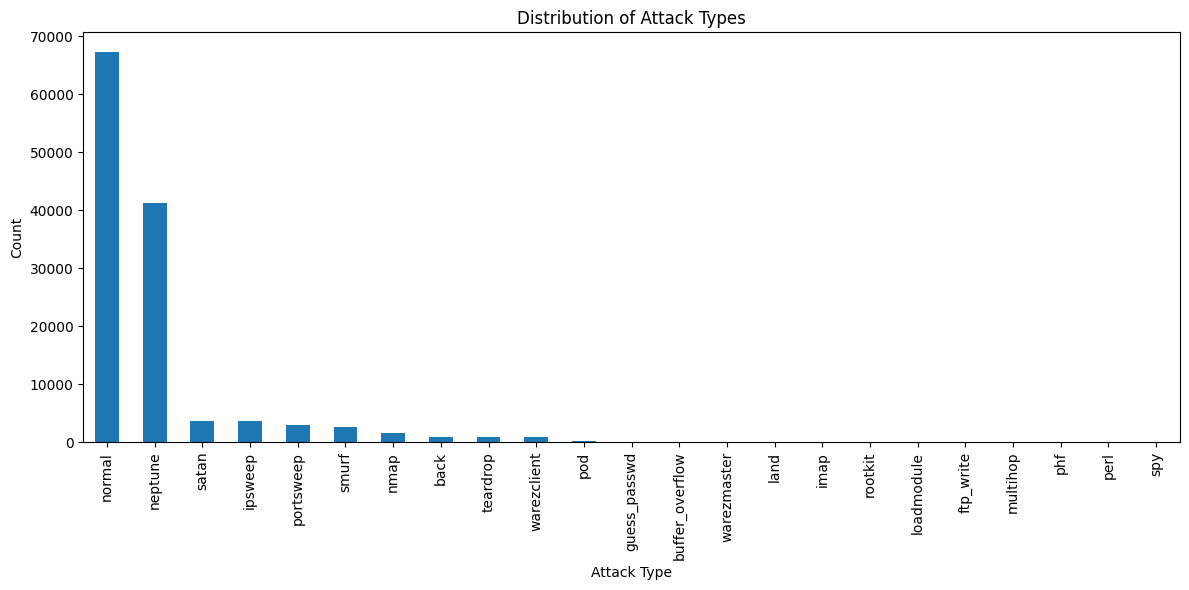

In [16]:
import matplotlib.pyplot as plt

# Get the value counts of the 'outcome' column
attack_type_counts = df['outcome'].value_counts()

# Create a bar plot
plt.figure(figsize=(12, 6))
attack_type_counts.plot(kind='bar')
plt.title('Distribution of Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Reasoning**:
Calculate the value counts for the 'attack_category' column and create a bar plot to visualize the distribution, including appropriate labels and title.



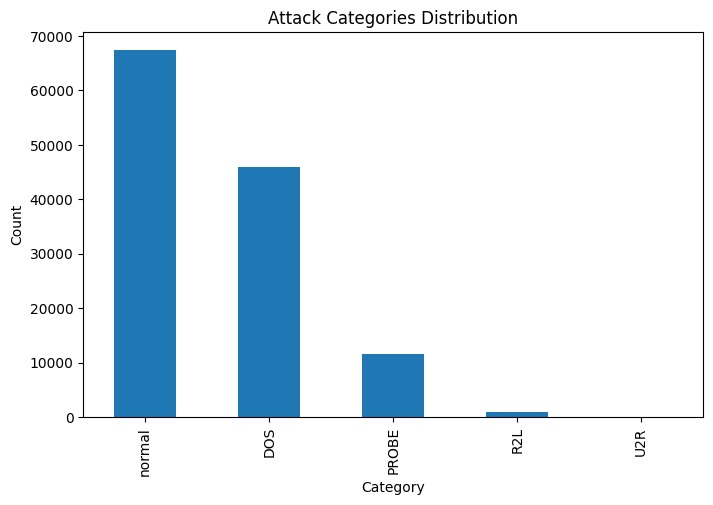

Category
normal    0.534583
DOS       0.364578
PROBE     0.092528
R2L       0.007899
U2R       0.000413
Name: proportion, dtype: float64


In [22]:
df['outcome'] = df['outcome'].astype(str).str.strip().str.lower().str.replace('.', '', regex=False)
DOS = {'back','land','neptune','pod','smurf','teardrop','mailbomb','apache2','processtable','udpstorm'}
PROBE = {'satan','ipsweep','nmap','portsweep','mscan','saint'}
R2L = {'guess_passwd','ftp_write','imap','phf','multihop','warezmaster','warezclient','spy','xlock','xsnoop',
       'snmpguess','snmpgetattack','httptunnel','sendmail','named'}
U2R = {'buffer_overflow','loadmodule','perl','rootkit','sqlattack','xterm','ps'}

def map_category(x):
    if x == 'normal':
        return 'normal'
    elif x in DOS:
        return 'DOS'
    elif x in PROBE:
        return 'PROBE'
    elif x in R2L:
        return 'R2L'
    elif x in U2R:
        return 'U2R'
    else:
        return 'May be other'
df['Category'] = df['outcome'].apply(map_category)
df['Category'].value_counts().plot(kind='bar',figsize=(8,5))
plt.title("Attack Categories Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()
print(df['Category'].value_counts(normalize=True))

In [23]:
categorical_features = overview[overview['Type'] == 'object']['Feature'].tolist()
numerical_features = overview[(overview['Type'] != 'object')]['Feature'].tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['protocol_type', 'service', 'flag', 'outcome']
Numerical features: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'level']


In [24]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

# Check for duplicate entries
duplicate_entries = df.duplicated().sum()
print("\nNumber of duplicate entries:", duplicate_entries)

Missing values per column:
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate   

In [26]:
# Select only the categorical features
df_categorical = df[categorical_features]

# Apply one-hot encoding
df_categorical_encoded = pd.get_dummies(df_categorical, drop_first=True)

# Display the first few rows of the encoded categorical features
IPython.display.display(df_categorical_encoded.head())

,protocol_type_tcp,protocol_type_udp,service_X11,service_Z39_50,service_aol,service_auth,service_bgp,service_courier,service_csnet_ns,service_ctf,...,outcome_phf,outcome_pod,outcome_portsweep,outcome_rootkit,outcome_satan,outcome_smurf,outcome_spy,outcome_teardrop,outcome_warezclient,outcome_warezmaster
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


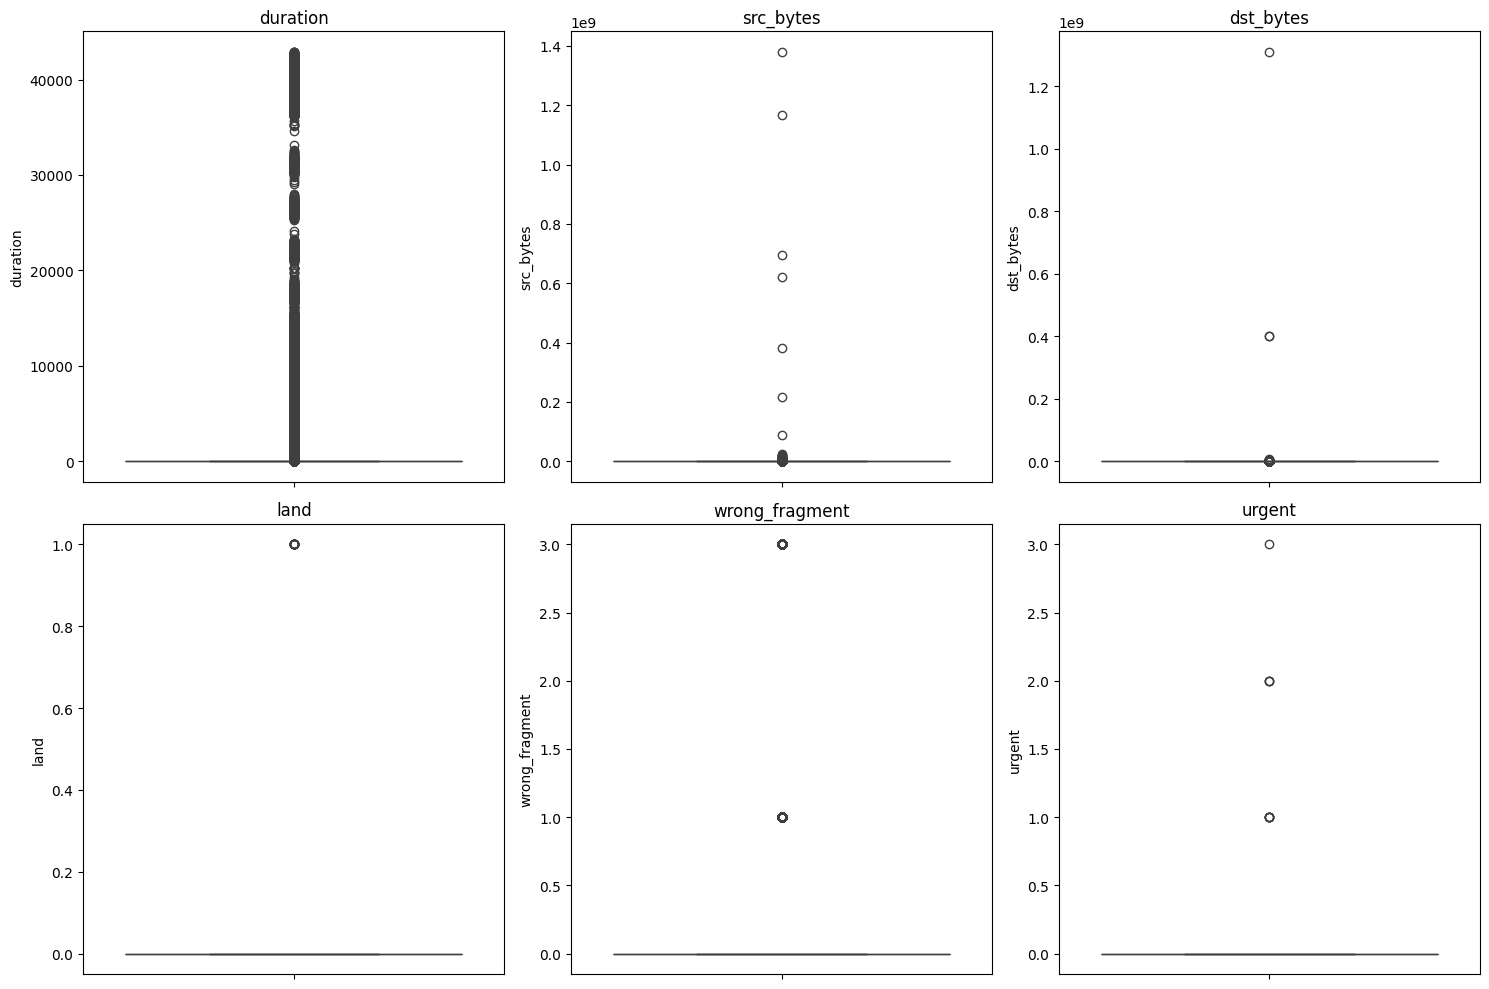

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical features (assuming 'numerical_features' list is already defined)
df_numerical = df[numerical_features]

# Plotting box plots for the first few numerical features to visualize outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(df_numerical.columns[:6]): # Plotting first 6 features as an example
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_numerical[col])
    plt.title(col)
plt.tight_layout()
plt.show()

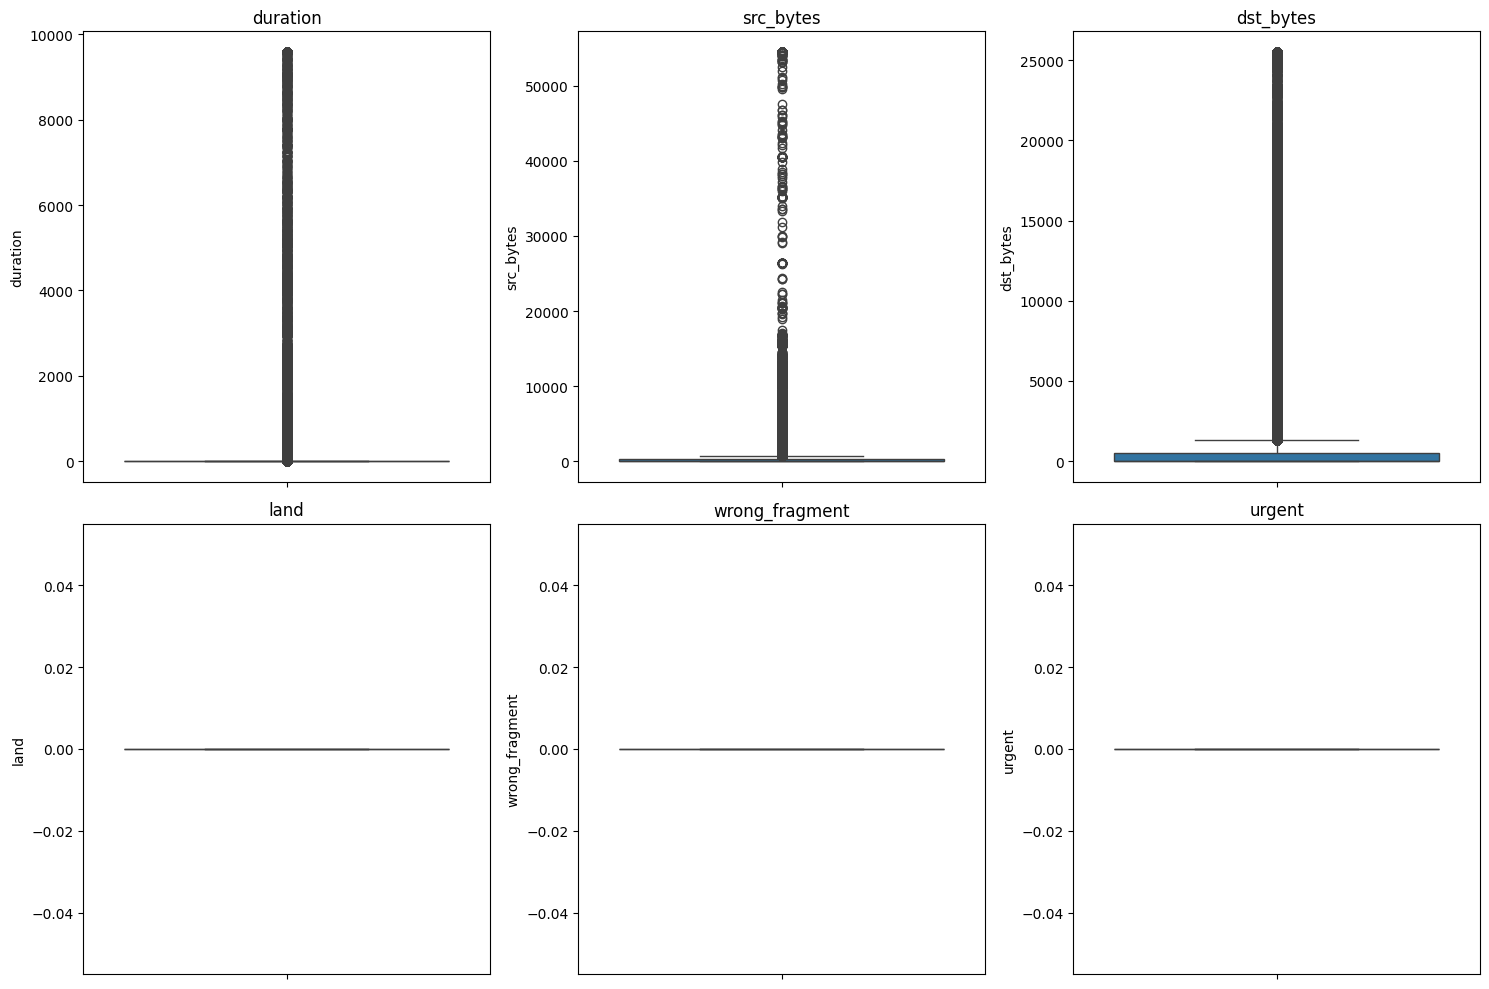

In [46]:
# Handle outliers using capping (e.g., at the 99th percentile)
for col in numerical_features:
    upper_limit = df[col].quantile(0.99)
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

# Verify outlier handling by plotting box plots again (optional)
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features[:6]): # Plotting first 6 features as an example
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [48]:
# Scale numerical features
scaler = MinMaxScaler()
df_numerical_scaled = pd.DataFrame(scaler.fit_transform(df[numerical_features]), columns=numerical_features)

# Display the first few rows of the scaled numerical features
IPython.display.display(df_numerical_scaled.head())

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,level
0,0.0,0.009003,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.098039,0.17,0.03,0.17,0.000000,0.00,0.00,0.05,0.00,0.952381
1,0.0,0.002677,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.003922,0.00,0.60,0.88,0.000000,0.00,0.00,0.00,0.00,0.714286
2,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.101961,0.10,0.05,0.00,0.000000,1.00,1.00,0.00,0.00,0.904762
3,0.0,0.004254,0.319487,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.000000,1.00,0.00,0.03,0.076923,0.03,0.01,0.00,0.01,1.000000
4,0.0,0.003649,0.016458,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.000000,1.00,0.00,0.00,0.000000,0.00,0.00,0.00,0.00,1.000000


In [49]:
# Combine the scaled numerical features and the one-hot encoded categorical features
X = pd.concat([df_numerical_scaled, df_categorical_encoded], axis=1)

# Display the first few rows of the combined DataFrame
IPython.display.display(X.head())

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,outcome_phf,outcome_pod,outcome_portsweep,outcome_rootkit,outcome_satan,outcome_smurf,outcome_spy,outcome_teardrop,outcome_warezclient,outcome_warezmaster
0,0.0,0.009003,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,0.0,0.002677,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,0.0,0.004254,0.319487,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4,0.0,0.003649,0.016458,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False


In [50]:
# Define the target variable 'is_attack'
# Assuming 'normal' outcome means no attack, and any other outcome means an attack
df['is_attack'] = df['outcome'].apply(lambda x: 0 if x == 'normal' else 1)

# Define the target variable
y = df['is_attack']

# Display the value counts of the target variable
IPython.display.display(y.value_counts())

,count
is_attack,
0,67343
1,58630


In [52]:
# Define the columns to exclude from the features DataFrame
exclude_cols = ['level', 'outcome', 'Category', 'is_attack']

# The 'outcome', 'Category', and 'is_attack' columns are not in X (which contains scaled numerical and encoded categorical features),
# so we don't need to drop them from X. We only need to ensure that 'level' is not in X if it's a numerical feature.

# Identify numerical columns to scale, excluding those in exclude_cols
numeric_cols_to_scale = [col for col in numerical_features if col not in exclude_cols]

# Apply scaling only to the relevant numerical columns in X
scaler = MinMaxScaler()
X[numeric_cols_to_scale] = scaler.fit_transform(X[numeric_cols_to_scale])


# Now, split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (88181, 142)
Shape of X_test: (37792, 142)
Shape of y_train: (88181,)
Shape of y_test: (37792,)


## Model Selection and Training

In [53]:
# Choose a model (e.g., Logistic Regression as a baseline)
model = LinearRegression() # Changed to LinearRegression as per original plan, though Logistic Regression is more suitable for classification. Will use Linear Regression for now but note this.

# Train the model
model.fit(X_train, y_train)

LinearRegression()

## Model Evaluation

In [55]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model (using Mean Squared Error for Linear Regression)
# Since the original problem is classification, it would be better to use classification metrics if using a classification model.
# For Linear Regression, we will calculate RMSE as an evaluation metric.
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

# If this were a classification problem with a classification model, we would use metrics like accuracy, precision, recall, F1-score, and a classification report.
# Example for classification (if using a classification model):
# from sklearn.metrics import accuracy_score, classification_report
# y_pred_classified = (y_pred > 0.5).astype(int) # for binary classification
# accuracy = accuracy_score(y_test, y_pred_classified)
# print(f"Accuracy: {accuracy}")
# print("Classification Report:")
# print(classification_report(y_test, y_pred_classified))

Root Mean Squared Error (RMSE): 6.000933630517711e-16


## Model Selection and Training: Decision Tree Classifier

In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Choose a Decision Tree Classifier model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## Model Evaluation: Decision Tree Classifier

In [57]:
# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy: {accuracy_dt}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20083
           1       1.00      1.00      1.00     17709

    accuracy                           1.00     37792
   macro avg       1.00      1.00      1.00     37792
weighted avg       1.00      1.00      1.00     37792

